In [ ]:
import jax.numpy as jnp
import numpy as np
import pandas as pd

from cosmologix import fitter

from sim_config import params as true_params
from sim_config import get_quality_mask

from getdist import MCSamples, plots

import matplotlib.pyplot as plt
%matplotlib inline

from ximinf import cosmo_helper as ch
from ximinf import data_helper as dh

cosmo = ch.get_canonical("PlanckBAO18")
cosmologix_cosmo = ch.to_cosmologix(cosmo)
fiducial_cosmo = cosmologix_cosmo

The compilation cache as grown to 2.12 GB.Caching is disabled for now.Clear the cache using `cosmologix clear-cache -j` to re-enable.Or directly from python: tools.clear_cache(jit=True)


In [ ]:
class Chi2:
    """Base class for least-squares residual blocks."""

    def __init__(self):
        self.data = None
        self.error = None

    # def residuals(self, params):
    #     """Unweighted residuals (data - model)."""
    #     raise NotImplementedError

    def weighted_residuals(self, params):
        """Returns residuals normalized by 1σ errors."""
        return self.residuals(params) / self.error

    def negative_log_likelihood(self, params):
        """Consistency helper (not used in Gauss-Newton)."""
        r = self.weighted_residuals(params)
        return jnp.sum(r**2)

    def initial_guess(self, params):
        return params

    # def draw(self, params):
    #     raise NotImplementedError

class DiagSNIaStandardisation(Chi2):

    def __init__(self, magobs, magobs_err,
                 x1, x1_err,
                 c, c_err,
                 coefs={}):

        super().__init__()

        self.data = jnp.atleast_1d(magobs)
        self.magerr = jnp.atleast_1d(magobs_err)

        self.x1 = jnp.atleast_1d(x1)
        self.x1_err = jnp.atleast_1d(x1_err)

        self.c = jnp.atleast_1d(c)
        self.c_err = jnp.atleast_1d(c_err)

        self.coefs = {k: jnp.atleast_1d(v) for k, v in coefs.items()}

    def model(self, params):

        return (
            params["M"]
            + params["alpha"] * params["x1"]
            + params["beta"] * params["c"]
            + params["gamma"] * self.coefs["p"]
        )

    def residuals(self, params):

        # --- SN Ia residuals ---
        r_m = self.data - self.model(params)

        # --- latent variable constraints ---
        r_x1 = params["x1"] - self.x1
        r_c  = params["c"]  - self.c

        return jnp.hstack([r_m, r_x1, r_c])

    def weighted_residuals(self, params):
        sigma = jnp.sqrt(
            self.magerr**2
            # + (params["alpha"]**2) * self.x1_err**2
            # + (params["beta"]**2) * self.c_err**2
            + true_params['sigma_int']**2
        )

        r_m = (self.data - self.model(params)) / sigma

        r_x1 = (params["x1"] - self.x1) / self.x1_err
        r_c  = (params["c"]  - self.c)  / self.c_err

        return jnp.hstack([r_m, r_x1, r_c])

    # def draw(self, params):

    #     self.data = (
    #         self.model(params)
    #         + tools.randn(self.magerr)
    #     )

    def initial_guess(self, params):
    
        return dict(
            params,
            M=0.0,
            alpha=-0.15,
            beta=3.3,
            gamma=0.17,
            x1=jnp.array(self.x1),
            c=jnp.array(self.c),  
        )



In [ ]:
file_path = "../data/inference_data_frame.h5"
params, data_dict = dh.load_hdf5(file_path)

In [ ]:
columns = ['magobs', 'magobs_err', 'c', 'c_err', 'x1', 'x1_err', 'isup', 'z']
data_dict, max_size = dh.filter_and_pad(data_dict, columns, get_quality_mask)
data_dict, mask = dh.remove_cosmology(data_dict, cosmologix_cosmo, disable_x64_after=False)
df = pd.DataFrame({
    k: np.asarray(v)[0]
    for k, v in data_dict.items()
})

In [5]:
z_cmb   = df["z"].to_numpy() #dtype=np.float32
mu_err  = df["magobs_err"].to_numpy()

coefs = {
    "x1": df["x1"].to_numpy(),
    "c":  df["c"].to_numpy(),
    "p":  df["isup"].to_numpy()
}

# Observed magnitudes
magobs = df["magobs"].to_numpy()

In [ ]:
likelihood = DiagSNIaStandardisation(
    magobs=magobs,
    magobs_err=mu_err,
    x1=df["x1"].to_numpy(),
    x1_err=df["x1_err"].to_numpy(),
    c=df["c"].to_numpy(),
    c_err=df["c_err"].to_numpy(),
    coefs=coefs
)

result = fitter.fit(
    [likelihood],
    fixed=fiducial_cosmo
)

param_names = ["M", "alpha", "beta", "gamma"]

# parameters of interest
params = ["alpha", "beta", "M", "gamma"]
indices = [param_names.index(p) for p in params]

mu = np.array(result["x"])              # best-fit values
cov = np.array(result["inverse_FIM"])   # covariance = inverse Fisher

mu_sub = mu[indices]
cov_sub = cov[np.ix_(indices, indices)]

rng = np.random.default_rng(0)
Nsamp = 2000

samples = rng.multivariate_normal(mu_sub, cov_sub, size=Nsamp)

Removed no burn in


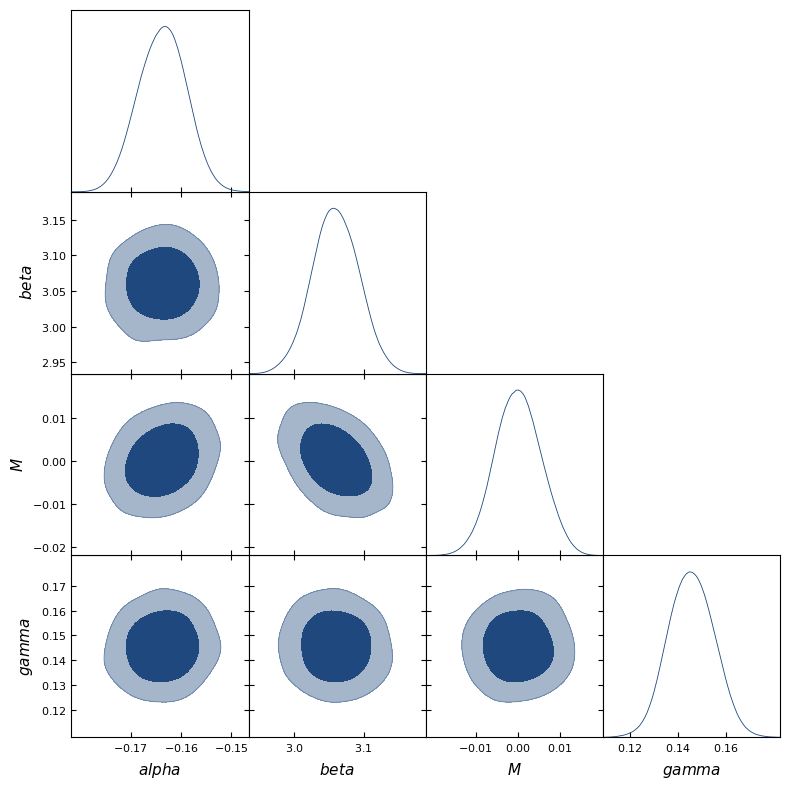

In [7]:
samples = np.asarray(samples)

gdsamples = MCSamples(
    samples=samples,
    names=params,
    labels=params,
)

g = plots.get_subplot_plotter()

g.triangle_plot(
    gdsamples,
    filled=True,
    contour_colors=["#1F487E"],
    # param_limits={
    #     name: r for name, r in zip(params, ranges_from_priors)
    # }
)

g.export("./corner.png")
plt.show()

In [8]:
np.save("../data/results/cosmologix_posterior_dict.npy", {
    "offset": samples[:, params.index("M")],
    # "alpha_low": post_unnormed[:, global_param_names.index("alpha_low")],
    # "alpha_high": post_unnormed[:, global_param_names.index("alpha_high")],
    "alpha": samples[:, params.index("alpha")],
    # "x1_ref": post_unnormed[:, global_param_names.index("x1_ref")],
    "beta": samples[:, params.index("beta")],
    "step": samples[:, params.index("gamma")],
    # "sigma_int": post_unnormed[:, global_param_names.index("sigma_int")]
    })